<div style="background-color:#5A3516; color:#F3EEE6; padding:22px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h1 style="color:#F3EEE6; margin-bottom:0;"><b>Machine Learning II — Customer Segmentation</b></h1>
<h3 style="color:#D8C0B4; margin-top:6px;">Notebook 0 — Data Analysis</h3>
<p style="color:#D8C0B4; font-size:15px; margin-top:14px;">
This notebook explores the raw <code>customer_info</code> dataset before any preprocessing decisions are applied. The objective is to understand structure, missingness, duplicates, distributions and potential data quality issues that motivate the cleaning workflow in Notebook 1.
</p>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:18px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin-top:0;"><b>Index</b></h2>
<p style="color:#D8C0B4;">This notebook focuses only on exploratory data analysis. No cleaned or transformed dataset is exported here.</p>
<ol>
  <li><a href="#section-1-imports-and-data-loading">Imports and data loading</a></li>
  <li><a href="#section-1-1-data-analysis">Initial data analysis</a></li>
  <li><a href="#section-1-2-duplicate-rows-analysis">Duplicate rows analysis</a></li>
  <li><a href="#section-1-2-1-surname-repetition-check">Surname repetition check</a></li>
  <li><a href="#section-1-3-missing-values-analysis">Missing values analysis</a></li>
  <li><a href="#section-1-4-numerical-and-categorical-columns">Numerical and categorical columns</a></li>
  <li><a href="#section-1-4-1-categorical-columns">Findings in categorical columns</a></li>
  <li><a href="#section-1-5-statistical-summary">Statistical summary and distribution checks</a></li>
</ol>
</div>

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1. Imports and Data Loading</b></h2>
</div>


In [1]:
import warnings

import pandas as pd

warnings.filterwarnings("ignore")

import utils_eda as utils

utils.set_plot_style()
pd.set_option("display.max_columns", None)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
We start by loading the libraries and the project utility module used for exploratory plots and summary tables. The actual cleaning decisions are kept for Notebook 1, so this notebook remains focused on understanding the raw data.
</div>

<a id="section-1-1-data-analysis"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.1 Initial Data Analysis</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

After loading the dataset, we inspect its shape, column types, and sample records. This gives us a quick sense of what needs to be cleaned before we start creating features for clustering.

</div>


In [2]:
DATA_PATH = "../datasets/customer_info.csv"
ci = pd.read_csv(DATA_PATH)

In [3]:
ci.sort_index(inplace=True)
display(ci.head())


,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,1133.0,972.0,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,718.0,1068.0,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [4]:
display(ci.tail())

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
33033,39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,NaN,190.0,573.0,994.0,1020.0,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
33034,39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,21.0,291.0,497.0,1417.0,1323.0,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
33035,39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,14.0,1600.0,494.0,117.0,307.0,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
33036,39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,11.0,596.0,303.0,661.0,NaN,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235
33037,40000,Sammie Wright,female,07/09/1990 10:27 AM,0.0,1.0,1.0,1.0,4774.0,2127.0,7.0,701.0,387.0,126.0,816.0,729.0,1331.0,323.0,239.0,102.0,0.252563,2017.0,NaN,38.758936,-9.145988


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
We use the `.info()` method to verify the column names, not null counts, and data types. This allows us to identify columns that require type conversion and gives us an initial glimpse of the data density.

In [5]:
display(ci.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   customer_birthdate                       32873 non-null  object 
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377

None

<a id="section-1-2-duplicate-rows-analysis"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.2 Duplicate Rows Analysis</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
To ensure the reliability of our clusters, we check for duplicate records. Duplicate rows can artificially inflate the importance of certain customer profiles and lead to biased segmentation results.

In [6]:
duplicate_rows = ci[ci.duplicated()]
display(duplicate_rows.head())

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
While checking for exact row duplicates is standard, it is also important to perform a more granular search for "logical duplicates". 

In this step, we specifically look for records that share the same **Customer Name** and **Birthdate**. Identifying such cases is vital because:
* **Data Overlap:** The same individual might have been registered twice under different IDs.
* **Clustering Bias:** If the same customer profile appears multiple times, it will unfairly pull a cluster center toward its specific attributes, distorting the final segmentation.

In [7]:
ci[ci[['customer_name', 'customer_birthdate']].duplicated()]

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude


<a id="section-1-2-1-surname-repetition-check"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.2.1 Surname Repetition Check</b></h2>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
Customer surnames are inspected as a possible household signal. This check is exploratory only: a repeated surname does not necessarily mean that customers belong to the same household, especially when common surnames appear many times in the dataset.
</div>

In [8]:
surname_overview, top_surnames = utils.surname_summary(ci)
display(surname_overview)
display(top_surnames)

,total_customers_with_name,unique_surnames,repeated_surnames,customers_with_repeated_surname,share_with_repeated_surname_%
0,33038,12060,4572,25550,77.34


,surname,customers
0,smith,364
1,johnson,311
2,williams,257
3,brown,228
4,jones,221
5,miller,171
6,davis,162
7,wilson,147
8,jackson,130
9,moore,124


In [9]:
surname_location_checks = pd.concat(
    [
        utils.surname_location_proxy(ci, decimals=4),
        utils.surname_location_proxy(ci, decimals=3),
    ],
    ignore_index=True,
)
display(surname_location_checks)

,rounding_decimals,groups_with_same_surname_location,customers_in_groups,share_of_named_customers_%
0,4,7,14,0.04
1,3,235,573,1.73


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
Surname repetition is high when considered alone, but this is expected because many surnames are common. When surname is combined with close geographic location, the number of reliable matches becomes much smaller. For this reason, surname is not used as a modelling feature; at most, it is treated as a weak exploratory proxy for potential households.
</div>

<a id="section-1-3-missing-values-analysis"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.3 Missing Values Analysis</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
    
Missing data is a common challenge in customer datasets. We generate a missing value report to:
* Quantify the percentage of missing information per feature.
* Visualize the missing data using a barplot.
* Determine which variables require **KNN Imputation** and which ones might be too empty to be useful.

In [10]:
missing_df = utils.get_missing_percent(ci)

In [11]:
display(missing_df.sort_values("Missing_Percent", ascending=False).head(15))

,Column,Missing_Percent
22,loyalty_card_number,39.67
15,lifetime_spend_fish,3.00
9,lifetime_spend_electronics,2.00
17,lifetime_spend_videogames,2.00
14,lifetime_spend_meat,2.00
11,lifetime_spend_vegetables,2.00
10,typical_hour,2.00
18,lifetime_spend_petfood,2.00
6,number_complaints,2.00
16,lifetime_spend_hygiene,1.00


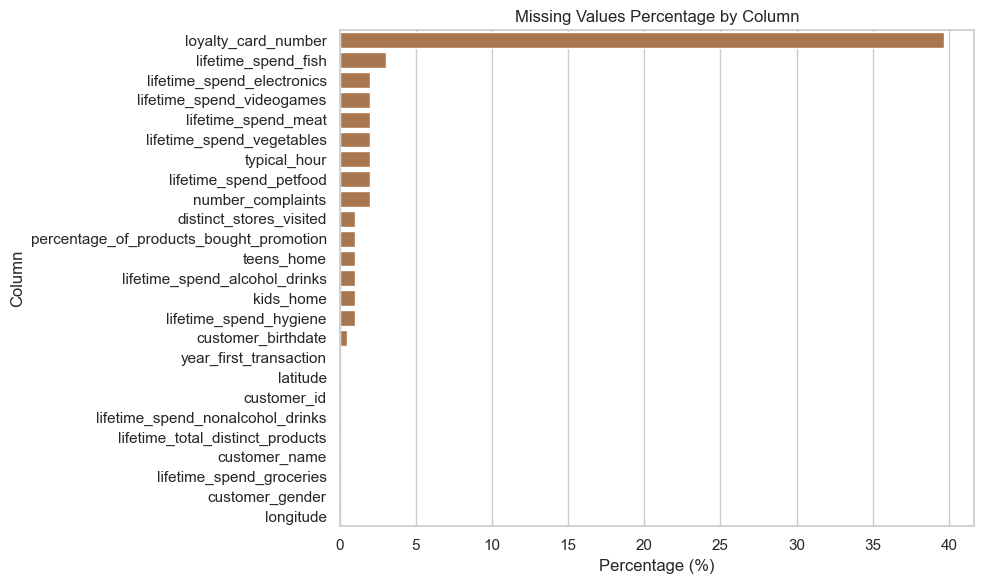

In [12]:
utils.plot_missing_percent(missing_df)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

We identify features with a missing value percentage higher than **30%**. This threshold is critical because:
* **Information Loss:** Variables with high sparsity often lack enough signal to be reliably imputed.
* **Model Integrity:** Including features with excessive missing data can introduce significant noise into the clustering process, potentially leading to distorted segments.


In [13]:
high_missing = missing_df[missing_df['Missing_Percent'] > 30]
display(high_missing)

,Column,Missing_Percent
22,loyalty_card_number,39.67


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The missing value inspection shows that the dataset is usable without dropping large parts of the customer base. The missing values are concentrated in a limited group of behavioural and spend variables, which supports using imputation later instead of removing customers prematurely.
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
We evaluate the number of unique values in the `loyalty_card_number` column to determine its nature.

In [14]:
print(f"Unique Values of column loyalty_card_number: {ci['loyalty_card_number'].nunique()}")

Unique Values of column loyalty_card_number: 1


<a id="section-1-4-numerical-and-categorical-columns"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.4 Numerical and Categorical Columns</b></h2>
</div>


In [15]:
numerical_cols, categorical_cols = utils.get_column_groups(ci)

print(f"Numerical columns ({len(numerical_cols)}):")
display(pd.DataFrame(numerical_cols, columns=["Numerical Columns"]))

print(f"Categorical columns ({len(categorical_cols)}):")
display(pd.DataFrame(categorical_cols, columns=["Categorical Columns"]))


Numerical columns (22):


,Numerical Columns
0,customer_id
1,kids_home
2,teens_home
3,number_complaints
4,distinct_stores_visited
5,lifetime_spend_groceries
6,lifetime_spend_electronics
7,typical_hour
8,lifetime_spend_vegetables
9,lifetime_spend_nonalcohol_drinks


Categorical columns (3):


,Categorical Columns
0,customer_name
1,customer_gender
2,customer_birthdate


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

To properly prepare our preprocessing pipeline, we categorize the variables into Numerical and Categorical types. This distinction is essential as each group requires specific cleaning and transformation strategies.

Numerical Features (21 Variables)
These columns represent quantitative data, including spending amounts, household counts, and geographic coordinates.
* **Household & Behavior:** `kids_home`, `teens_home`, `number_complaints`, `distinct_stores_visited`.
* **Spending Habits:** `lifetime_spend_` (Groceries, Electronics, Vegetables, Non alcoholic, Alcohol, Meat, Fish, Hygiene, Videogames, Petfood).
* **Metrics & Time:** `lifetime_total_distinct_products`, `percentage_of_products_bought_promotion`, `typical_hour`, `year_first_transaction`.
* **Geospatial & IDs:** `latitude`, `longitude`, `loyalty_card_number`.

Categorical Features (3 Variables)
These columns contain qualitative information or timestamps that define the customer profile.
* **Demographics:** `customer_gender`.
* **Identification:** `customer_name`.
* **Temporal:** `customer_birthdate` (to be used for age calculation).

</div>

<a id="section-1-4-1-categorical-columns"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.4.1 Findings in Categorical Columns</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

A detailed inspection of the `customer_name` field shows that several names include academic prefixes such as **BSc.**, **MSc.**, and **PhD.**

* **Observation:** The dataset contains 33,038 unique customer names.
* **Feature Engineering Opportunity:** These prefixes can be used as a proxy for the customer's **education level**. They are converted into approximate years of education: 12 for customers without a prefix, 15 for BSc, 17 for MSc, and 22 for PhD.
* **Data Cleaning:** After extracting this information, the raw name field is no longer needed for modelling.

</div>


<a id="section-1-5-statistical-summary"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1.5 Statistical Summary</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
    
We perform a statistical summary of the numerical features using the `.describe()` method. This allows us to observe the central tendency, dispersion, and range of our variables, providing critical insights into the data's distribution.


In [17]:
print("Statistical summary for numerical columns:")
ci[numerical_cols].describe().T

Statistical summary for numerical columns:


,count,mean,std,min,25%,50%,75%,max
customer_id,33038.0,19974.265785,11538.538632,3.000000,9985.250000,19951.500000,29964.750000,40000.000000
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

Based on the summary table, we can identify several areas that require attention during preprocessing:

* **Constant Features:** `loyalty_card_number` does not add useful behavioural information for clustering.
* **Data Entry Errors:** `percentage_of_products_bought_promotion` contains impossible values below 0, and `year_first_transaction` contains future years.
* **Spending Variance:** The spending variables show strong dispersion, suggesting heterogeneous purchasing behaviour and the presence of extreme customers.
* **Missing Data:** Several columns have incomplete values and therefore require treatment before modelling.

</div>


In [18]:
condition = (ci['percentage_of_products_bought_promotion'] < 0.0) | (ci['percentage_of_products_bought_promotion'] > 1.0)
rows_wrong = ci[condition]
display(rows_wrong.head())

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
8,12,Phd. Dorothy Pacheco,female,05/19/2000 03:02 AM,0.0,0.0,0.0,2.0,9281.0,254.0,18.0,125.0,60.0,1549.0,139.0,598.0,673.0,71.0,64.0,29.0,-0.131176,2018.0,NaN,38.748616,-9.167756
26,35,Bsc. Thomas King,male,08/08/1979 05:25 AM,NaN,1.0,0.0,2.0,37795.0,2130.0,8.0,636.0,102.0,310.0,890.0,844.0,842.0,42.0,524.0,212.0,-0.025524,2011.0,1.0,38.762036,-9.158847
28,37,Phd. Alonzo Crossan,male,09/29/2000 07:54 PM,1.0,1.0,0.0,5.0,25539.0,1089.0,7.0,907.0,1681.0,896.0,1153.0,962.0,1205.0,344.0,329.0,330.0,-0.184820,2028.0,1.0,38.729700,-9.196585
65,81,Phd. Denise Allard,female,03/18/1992 06:34 PM,2.0,0.0,2.0,1.0,6273.0,430.0,6.0,208.0,291.0,525.0,539.0,804.0,707.0,121.0,320.0,91.0,-0.217805,2020.0,1.0,38.748092,-9.155615
71,87,Phd. Milagro Amelung,female,09/03/1977 11:26 AM,1.0,1.0,1.0,3.0,28825.0,2948.0,15.0,459.0,687.0,716.0,884.0,1495.0,1314.0,161.0,916.0,337.0,-0.022180,2008.0,1.0,38.776791,-9.146792


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

We perform a targeted integrity check on the `percentage_of_products_bought_promotion` feature. Since this variable represents a ratio, any value outside the range of **[0, 1]** is considered a data entry error.

* **Condition defined:** We filter for values strictly less than 0.0 or greater than 1.0.
* **Findings:** As noted in the descriptive statistics, there are records with negative values (e.g., -1.27), which are physically impossible.
* **Objective:** Identifying these specific rows allows us to treat them as "missing data" (NaN), ensuring they are later corrected by our **KNN Imputation** strategy rather than biasing our analysis with impossible values.

</div>

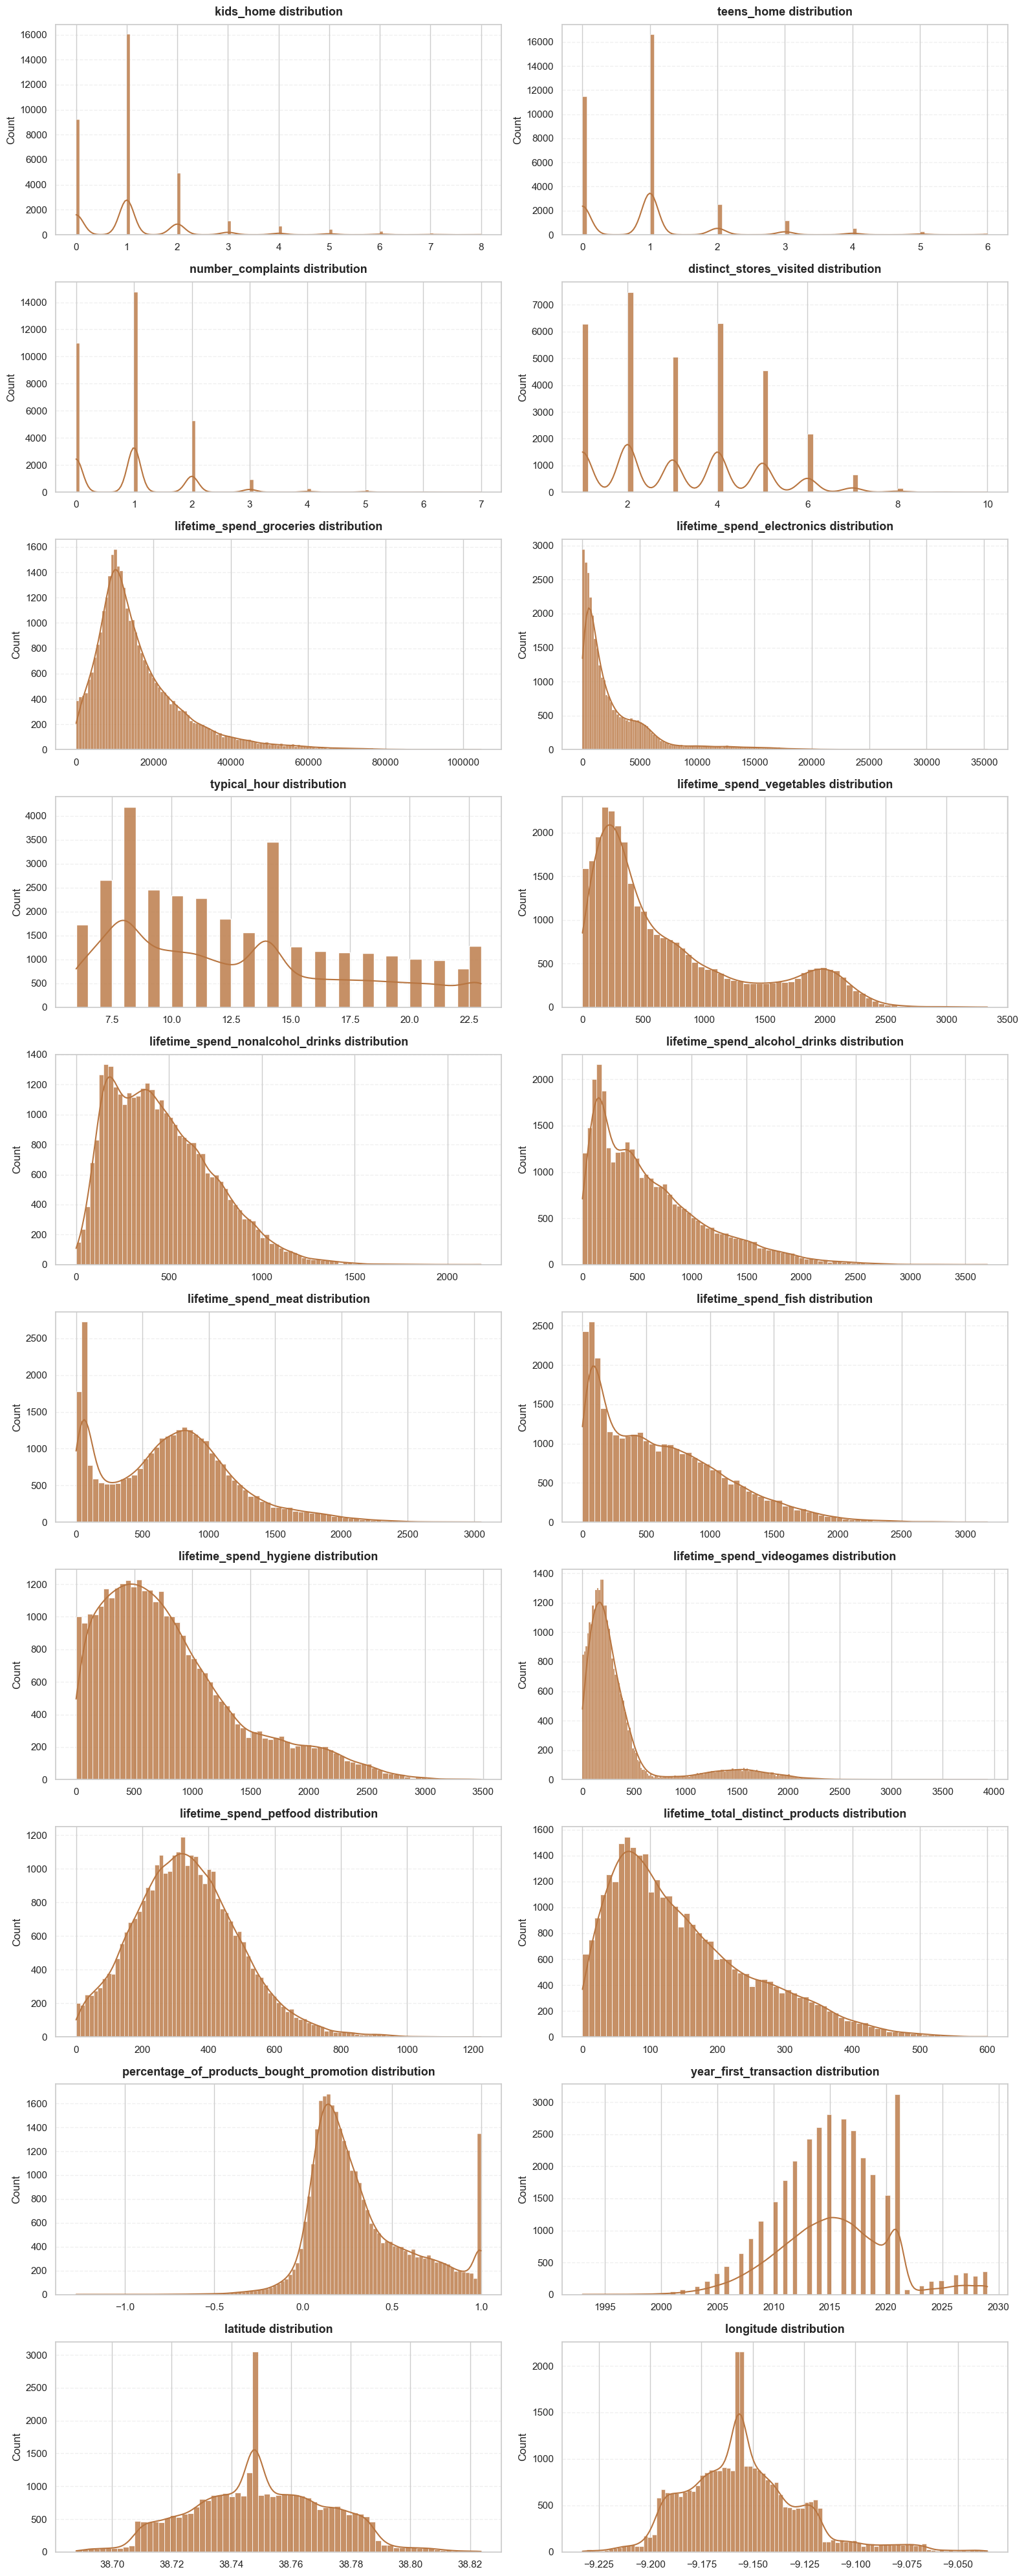

In [19]:
vars_to_plot = utils.numeric_columns_for_eda(
    ci,
    exclude_cols=["loyalty_card_number", "customer_id", "customer_loyalty_flag"],
)

utils.plot_numeric_distributions(ci, vars_to_plot)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

The histograms and boxplots provide an overview of the distribution and variability within the customer base.

#### **Spending Categories**
Most spending variables are right-skewed, meaning that the majority of customers spend relatively low amounts, while a smaller group shows significantly higher spending levels. The boxplots also highlight the presence of extreme values, which are handled separately to prevent them from overly influencing the clustering process.

#### **Temporal and Behavioral Patterns**
The typical shopping hour is treated as a cyclical variable, using sine and cosine transformations to preserve the relationship between late-night and early-morning activity. Additionally, the promotion percentage helps identify customers who are more sensitive to discounts and promotional campaigns.

</div>


In [20]:
display(utils.get_skewness_table(ci, vars_to_plot))


,feature,skewness
5,lifetime_spend_electronics,2.533751
13,lifetime_spend_videogames,2.427626
0,kids_home,2.123606
1,teens_home,1.898104
4,lifetime_spend_groceries,1.808936
2,number_complaints,1.344178
9,lifetime_spend_alcohol_drinks,1.199248
12,lifetime_spend_hygiene,1.035438
7,lifetime_spend_vegetables,1.035036
15,lifetime_total_distinct_products,0.947159


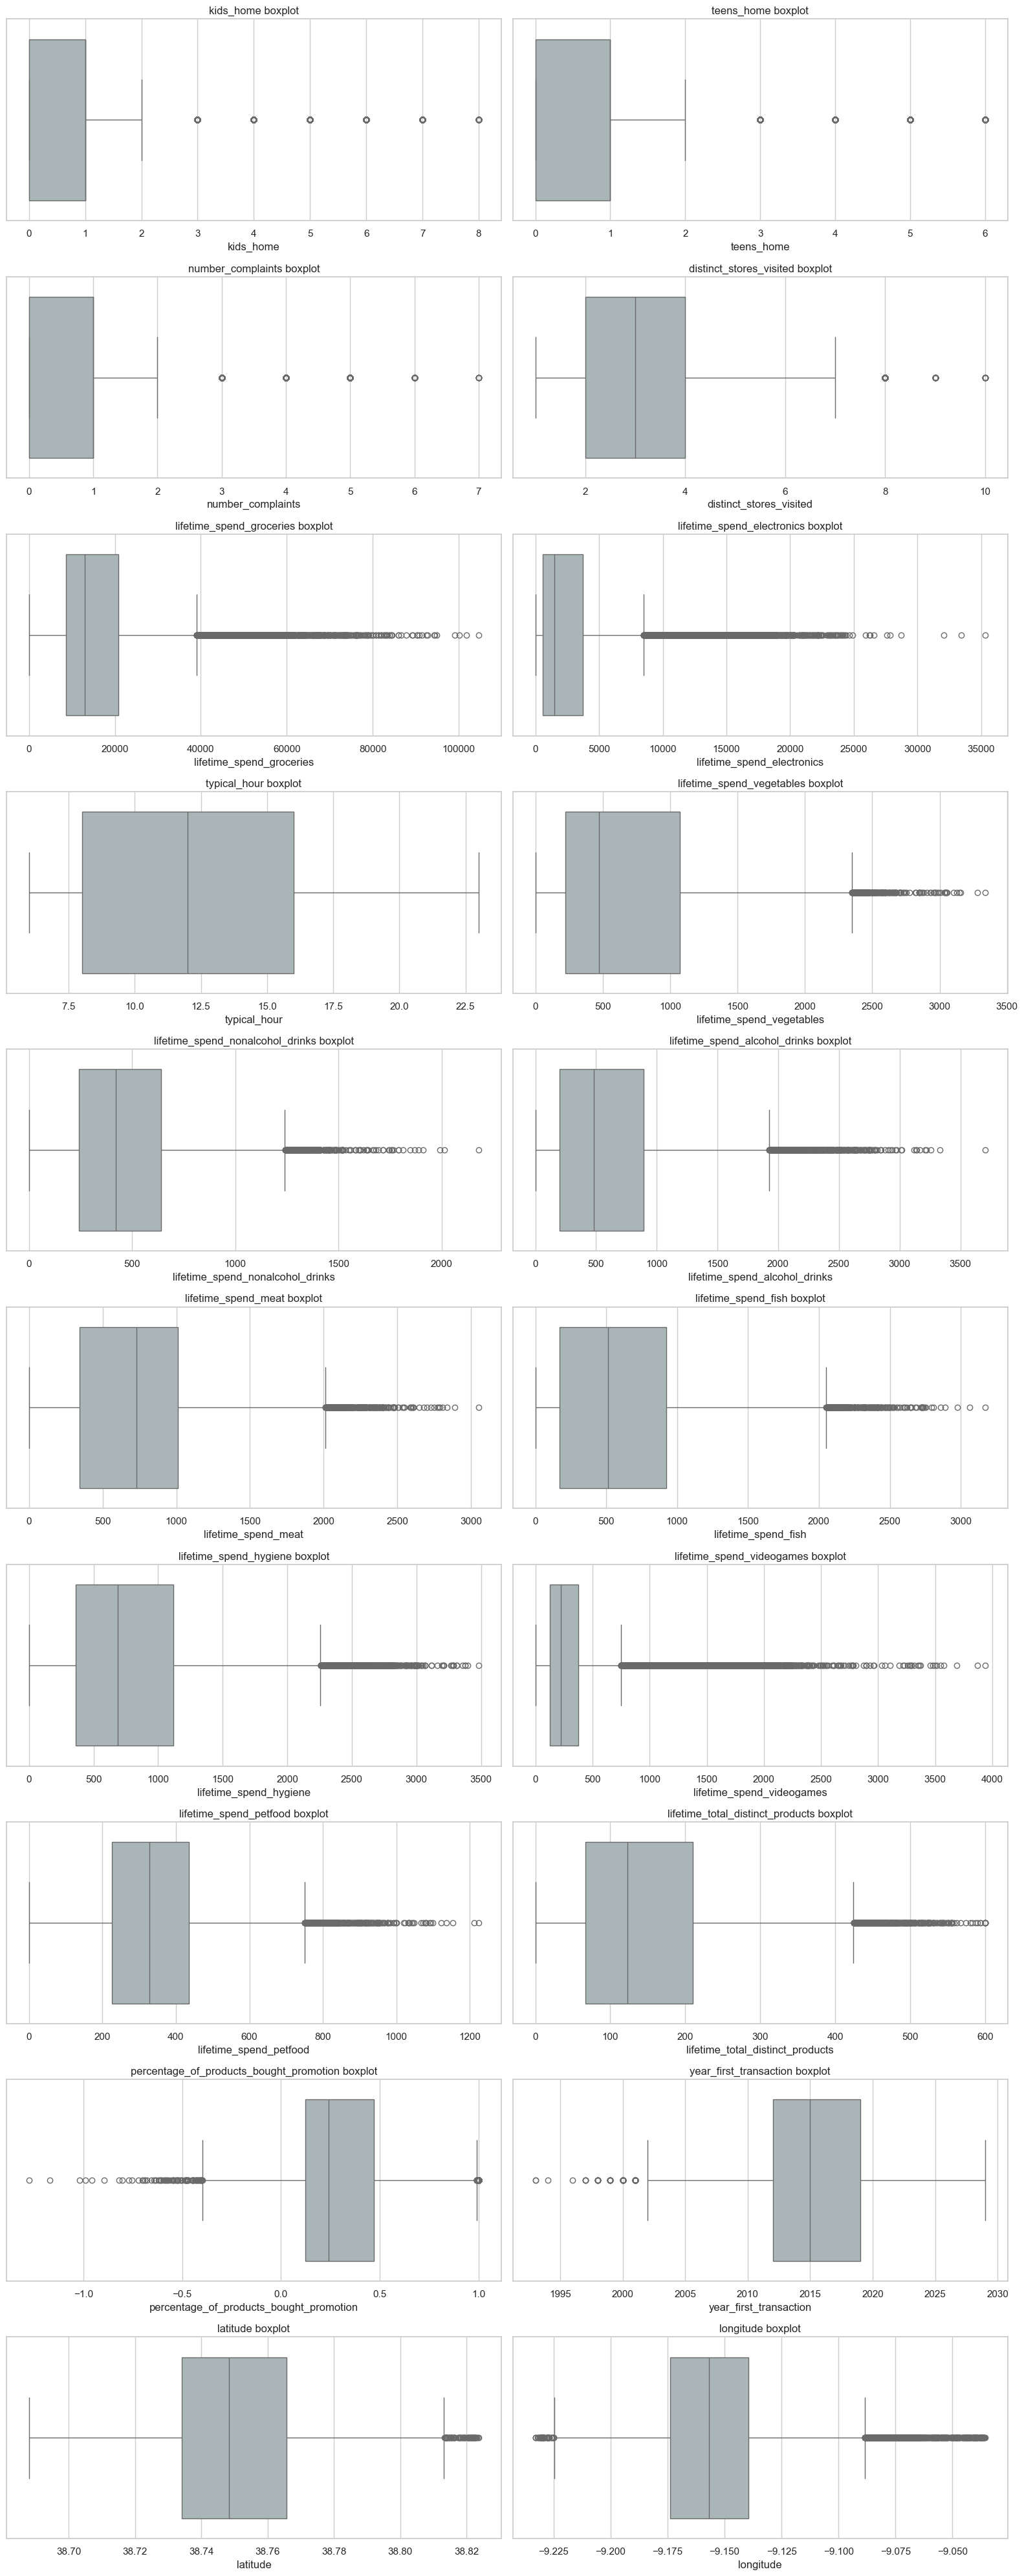

In [21]:
utils.plot_numeric_boxplots(ci, vars_to_plot)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

The distribution plots show that spending variables are highly right-skewed, with most customers spending relatively low amounts and a small group spending much more.

This supports two important modelling decisions: first, separating the most atypical customers before clustering; and second, treating scaling as a modelling choice in the clustering notebook.

</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Data analysis conclusion.</b><br><br>
The raw customer data contains missing values, skewed spending variables, identifier columns, date fields and several variables that require type conversion before modelling. These findings motivate the preprocessing notebook, where invalid values are handled, categorical information is encoded, outliers are separated and engineered features are exported for clustering.
</div>